# Validation Strategy

During Exploratory Data Analysis we found out the following facts:
- Train span: 182.00 days (`DT` 86,400 → 15,811,131)
- Test span: 183.00 days (`DT` 18,403,224 → 34,214,345)
- **Gap between end of train and start of test: exactly 30.00 days**
- Total combined span: 395 days

There's a full month of unseen time between the last training transaction and the first test transaction. Any local validation scheme that doesn't reproduce this gap may fail to be efficient and trustfull.

## Chosen Strategy: Single Time-Based Holdout Split with a 30-Day Purge Gap

**Visuality**: [--------------- Train (up to day D) ---------------] -> 30-day Gap -> [Validation]

**Single Time-Based Holdout Split (primary, for fast iteration)**  
Instead of a default and simple 80/20 cut, we can mirror a 30-day gap as it is in train/test.
* Training Set (Days 1 to 122): The first ~4 months of data are used exclusively for model training.
* Purge Gap (Days 123 to 152): The next 30 days are completely dropped from both training and validation.
* Validation Set (Days 153 to 182): The final 30 days of the available training data serve as the local validation benchmark.

## Motivation
* **Simulating the real test environment**: A local validation scheme that does not reproduce this blind spot of 30-day gap will fail to measure how well the model generalizes across temporal drift.
* **Preventing temporal leakage**: Standard random K-fold Cross-Validation allows the model to train on future data to predict the past, leading to artificially inflated local scores. This strict chronological cutoff guarantees that no future information leaks into the training phase.
* **Maximazing data efficiency**: Implementing a full time-series K-fold cross-validation with 30-day gaps would starve the early folds of historical context (e.g., training a fold on only 60 days of data). A single holdout split ensures the model trains on a sufficiently deep historical baseline (4 months) to learn user behaviors, seasonal trends, overall dynamics.

## Reasons for High Correlation with Leaderboard results:
* Strict chronological boundaries and timeline
* Time-Invariant feature engineering

## Reasons for Low Correlation with Leaderboard results:
* Genuine concept drift beyond 30 days — if fraud patterns shift meaningfully within that month, we can no longer accurately predict the results.
* The risk of missing out of important patterns in month 5 (30-day gap we created)

# Adversarial Validation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import math
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import gc
import warnings


pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [3]:
from google.colab import files
files.upload()  # select kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c ieee-fraud-detection
!unzip -q ieee-fraud-detection.zip -d data/

Saving kaggle.json to kaggle (2).json
ieee-fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)
replace data/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace data/test_identity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace data/test_transaction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace data/train_identity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace data/train_transaction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [4]:
def reduce_mem_usage(df, verbose=True):
    """Safely downcasts numeric columns without overflow or precision loss."""
    start_mem = df.memory_usage().sum() / 1024**2

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        for col in df.columns:
            col_type = df[col].dtype

            # Skip objects, categoricals, and datetimes
            if col_type != object and col_type.name != 'category' and not pd.api.types.is_datetime64_any_dtype(df[col]):
                c_min = df[col].min()
                c_max = df[col].max()

                # Skip columns containing infinite values to prevent overflow errors
                if np.isinf(c_min) or np.isinf(c_max):
                    continue

                if str(col_type)[:3] == 'int':
                    if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                        df[col] = df[col].astype(np.int8)
                    elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                        df[col] = df[col].astype(np.int16)
                    elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                        df[col] = df[col].astype(np.int32)
                    elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                        df[col] = df[col].astype(np.int64)
                else:
                    # Keep float32 as minimum target for stable training in sklearn/models
                    if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                        df[col] = df[col].astype(np.float32)
                    else:
                        df[col] = df[col].astype(np.float64)

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage decreased to {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

*Note: The code above was written with a help from Gemini to save some memory and not to have crashes*

In [5]:
print("Loading Train...")
train_tx = pd.read_csv('data/train_transaction.csv')
train_id = pd.read_csv('data/train_identity.csv')

train = train_tx.merge(train_id, on='TransactionID', how='left')

del train_tx, train_id
gc.collect()

train = reduce_mem_usage(train)

print("\nLoading Test...")
test_tx = pd.read_csv('data/test_transaction.csv')
test_id = pd.read_csv('data/test_identity.csv')

test = test_tx.merge(test_id, on='TransactionID', how='left')

del test_tx, test_id
gc.collect()

test = reduce_mem_usage(test)

print(f"\nFinal Train shape: {train.shape}")
print(f"Final Test shape: {test.shape}")

Loading Train...
Memory usage decreased to 1044.70 MB (46.6% reduction)

Loading Test...
Memory usage decreased to 895.89 MB (46.5% reduction)

Final Train shape: (590540, 434)
Final Test shape: (506691, 433)


In [6]:
SAMPLE_SIZE = 50000

# common columns excluding target and ID proxies
common_cols = [c for c in train.columns if c in test.columns and c not in ['isFraud', 'TransactionID']]

numeric_cols = train[common_cols].select_dtypes(include=['number']).columns.tolist()

# sample rows and cast to float32
s_train = train[numeric_cols].sample(n=min(SAMPLE_SIZE, len(train)), random_state=42).astype(np.float32)
s_test = test[numeric_cols].sample(n=min(SAMPLE_SIZE, len(test)), random_state=42).astype(np.float32)

adv_df = pd.concat([s_train, s_test], ignore_index=True).copy()

# build target array directly without modifying adv_df columns
y_adv = np.array([0] * len(s_train) + [1] * len(s_test))

del s_train, s_test
gc.collect()

def run_adversarial_validation(feature_cols, label=""):
    X = adv_df[feature_cols]

    # Preprocessing
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    del X_imputed
    gc.collect()

    clf = LogisticRegression(max_iter=1000, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # n_jobs=1 prevents parallel worker memory spikes
    scores = cross_val_score(clf, X_scaled, y_adv, cv=cv, scoring='roc_auc', n_jobs=1)

    print(f"=== Adversarial Validation {label} ===")
    print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores


# baseline WITH TransactionDT
cols_with_dt = numeric_cols

# EXCLUDE TransactionDT, ALL raw D-columns, and DT derivatives
time_leaking_cols = ['TransactionDT', 'DT_day'] + \
                     [c for c in numeric_cols if c.startswith('D') and not c.endswith('_detrended')]

cols_no_time = [c for c in numeric_cols if c not in time_leaking_cols]

# experiments
scores_with_dt = run_adversarial_validation(cols_with_dt, label="(including TransactionDT)")
scores_no_time = run_adversarial_validation(cols_no_time, label="(excluding TransactionID, Time & ALL Raw D-Cols)")

=== Adversarial Validation (including TransactionDT) ===
Mean AUC: 1.0000 (+/- 0.0000)
=== Adversarial Validation (excluding TransactionID, Time & ALL Raw D-Cols) ===
Mean AUC: 0.7235 (+/- 0.0022)


In [7]:
pca_cols = [c for c in train.columns if c.startswith('V') and c in test.columns]

print(f"Applying PCA on {len(pca_cols)} features...")

X_train_pca = train[pca_cols].astype(np.float32)
X_test_pca = test[pca_cols].astype(np.float32)

# impute missing values (fit on train, transform test)
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_pca)
X_test_imp = imputer.transform(X_test_pca)

del X_train_pca, X_test_pca
gc.collect()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

del X_train_imp, X_test_imp
gc.collect()

N_COMPONENTS = 0.95
pca = PCA(n_components=N_COMPONENTS, random_state=42)

train_pca_feats = pca.fit_transform(X_train_scaled)
test_pca_feats = pca.transform(X_test_scaled)

del X_train_scaled, X_test_scaled
gc.collect()

pca_col_names = [f'PCA_{i+1}' for i in range(pca.n_components_)]

for i, col in enumerate(pca_col_names):
    train[col] = train_pca_feats[:, i].astype(np.float32)
    test[col] = test_pca_feats[:, i].astype(np.float32)

print(f"Explained variance ratio total ({N_COMPONENTS} components): {pca.explained_variance_ratio_.sum():.4f}")

train.drop(columns=pca_cols, inplace=True)
test.drop(columns=pca_cols, inplace=True)

del train_pca_feats, test_pca_feats
gc.collect()

Applying PCA on 339 features...


/tmp/ipykernel_11622/2287053547.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col] = train_pca_feats[:, i].astype(np.float32)
/tmp/ipykernel_11622/2287053547.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[col] = test_pca_feats[:, i].astype(np.float32)
/tmp/ipykernel_11622/2287053547.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To

Explained variance ratio total (0.95 components): 0.9507


0

In [8]:
SAMPLE_SIZE = 50000

# common columns excluding target and ID proxies
common_cols = [c for c in train.columns if c in test.columns and c not in ['isFraud', 'TransactionID']]

numeric_cols = train[common_cols].select_dtypes(include=['number']).columns.tolist()

# sample rows and cast to float32
s_train = train[numeric_cols].sample(n=min(SAMPLE_SIZE, len(train)), random_state=42).astype(np.float32)
s_test = test[numeric_cols].sample(n=min(SAMPLE_SIZE, len(test)), random_state=42).astype(np.float32)

adv_df = pd.concat([s_train, s_test], ignore_index=True).copy()

# build target array directly without modifying adv_df columns
y_adv = np.array([0] * len(s_train) + [1] * len(s_test))

del s_train, s_test
gc.collect()

def run_adversarial_validation(feature_cols, label=""):
    X = adv_df[feature_cols]

    # Preprocessing
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    del X_imputed
    gc.collect()

    clf = LogisticRegression(max_iter=1000, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # n_jobs=1 prevents parallel worker memory spikes
    scores = cross_val_score(clf, X_scaled, y_adv, cv=cv, scoring='roc_auc', n_jobs=1)

    print(f"=== Adversarial Validation {label} ===")
    print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores


# baseline WITH TransactionDT
cols_with_dt = numeric_cols

# EXCLUDE TransactionDT, ALL raw D-columns, and DT derivatives
time_leaking_cols = ['TransactionDT', 'DT_day'] + \
                     [c for c in numeric_cols if c.startswith('D') and not c.endswith('_detrended')]

cols_no_time = [c for c in numeric_cols if c not in time_leaking_cols]

# experiments
scores_with_dt = run_adversarial_validation(cols_with_dt, label="(including TransactionDT)")
scores_no_time = run_adversarial_validation(cols_no_time, label="(excluding TransactionID, Time & ALL Raw D-Cols)")

=== Adversarial Validation (including TransactionDT) ===
Mean AUC: 0.9999 (+/- 0.0001)
=== Adversarial Validation (excluding TransactionID, Time & ALL Raw D-Cols) ===
Mean AUC: 0.7035 (+/- 0.0014)


*Note: Gemini and Claude were used to help write a correct strcture for Adversarial Validation and how it should look like.*

Top 15 features driving Train/Test separation (excluding time leakage):
C12       11.529416
C11       10.886278
C4         9.110816
C7         8.255758
C9         3.282166
C6         2.376269
PCA_50     1.921706
PCA_49     1.874050
PCA_51     1.510421
C14        1.504440
C8         1.451673
PCA_48     1.139967
C2         0.912734
PCA_23     0.692226
PCA_63     0.559887
dtype: float64


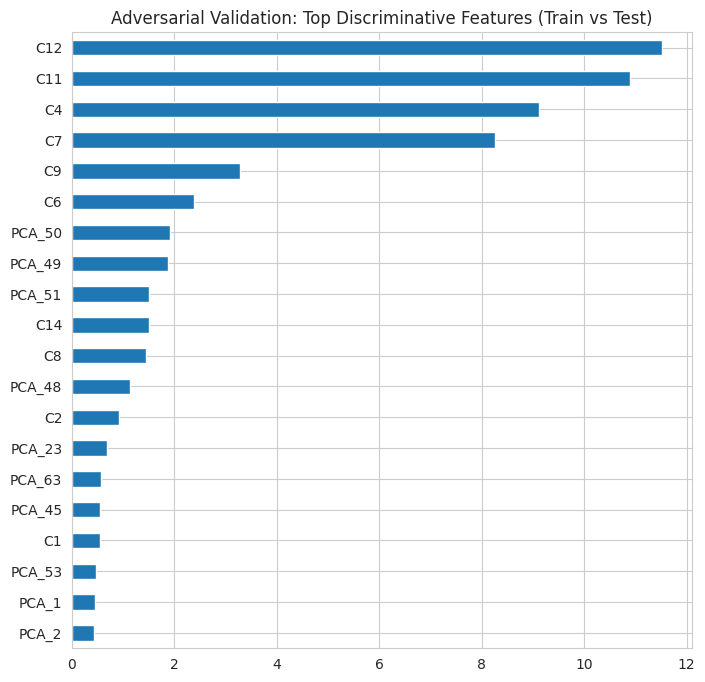

In [9]:
# ── Feature importance: ──
X_full = adv_df[cols_no_time].copy()
X_imputed = SimpleImputer(strategy='median').fit_transform(X_full)
X_scaled = StandardScaler().fit_transform(X_imputed)

clf_full = LogisticRegression(max_iter=1000, random_state=42)
clf_full.fit(X_scaled, y_adv)

importance = pd.Series(np.abs(clf_full.coef_[0]), index=cols_no_time).sort_values(ascending=False)
print("Top 15 features driving Train/Test separation (excluding time leakage):")
print(importance.head(15))

importance.head(20).plot(kind='barh', figsize=(8,8))
plt.title('Adversarial Validation: Top Discriminative Features (Train vs Test)')
plt.gca().invert_yaxis()
plt.show()

In [11]:
# We try to drop highest-scoring features to see if that would benefit Adversarial Validation
# If it improves the results, we may frop these features so our model won't overfit

features_to_drop = [
    'C12', 'C10', 'C4', 'C7'
]

existing_drops_train = [c for c in features_to_drop if c in train.columns]
existing_drops_test = [c for c in features_to_drop if c in test.columns]

train.drop(columns=existing_drops_train, inplace=True)
test.drop(columns=existing_drops_test, inplace=True)

print(f"Successfully dropped {len(existing_drops_train)} features from train and test.")
print("Remaining features in train:", train.shape[1])

assert not any(col in train.columns for col in features_to_drop), "Error: Some features were not dropped."

Successfully dropped 0 features from train and test.
Remaining features in train: 182


In [12]:
SAMPLE_SIZE = 50000

# common columns excluding target and ID proxies
common_cols = [c for c in train.columns if c in test.columns and c not in ['isFraud', 'TransactionID']]

numeric_cols = train[common_cols].select_dtypes(include=['number']).columns.tolist()

# sample rows and cast to float32
s_train = train[numeric_cols].sample(n=min(SAMPLE_SIZE, len(train)), random_state=42).astype(np.float32)
s_test = test[numeric_cols].sample(n=min(SAMPLE_SIZE, len(test)), random_state=42).astype(np.float32)

adv_df = pd.concat([s_train, s_test], ignore_index=True).copy()

# build target array directly without modifying adv_df columns
y_adv = np.array([0] * len(s_train) + [1] * len(s_test))

del s_train, s_test
gc.collect()

def run_adversarial_validation(feature_cols, label=""):
    X = adv_df[feature_cols]

    # Preprocessing
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    del X_imputed
    gc.collect()

    clf = LogisticRegression(max_iter=1000, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # n_jobs=1 prevents parallel worker memory spikes
    scores = cross_val_score(clf, X_scaled, y_adv, cv=cv, scoring='roc_auc', n_jobs=1)

    print(f"=== Adversarial Validation {label} ===")
    print(f"Mean AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores


# baseline WITH TransactionDT
cols_with_dt = numeric_cols

# EXCLUDE TransactionDT, ALL raw D-columns, and DT derivatives
time_leaking_cols = ['TransactionDT', 'DT_day'] + \
                     [c for c in numeric_cols if c.startswith('D') and not c.endswith('_detrended')]

cols_no_time = [c for c in numeric_cols if c not in time_leaking_cols]

# experiments
scores_no_time = run_adversarial_validation(cols_no_time, label="(excluding TransactionID, Time & ALL Raw D-Cols + Dropped Columns)")

=== Adversarial Validation (excluding TransactionID, Time & ALL Raw D-Cols + Dropped Columns) ===
Mean AUC: 0.6794 (+/- 0.0037)


# Conclusions

We trained a Logistic Regression classifier to distinguish train rows from test rows (5-fold stratified CV, AUC scoring), to check whether local validation results can be trusted.

* With TransactionDT/TransactionID included: AUC ≈ 1.0000. This is expected — Train and Test are separated by a strict chronological (and gap) split, so any time-correlated column trivially identifies the split.
* Excluding ID, time, and all raw D-columns: AUC dropped to 0.7235, showing that even after removing all time-related columns Train and Test are still distinguishable.
* After replacing the 339 V-columns with block-wise PCA components (95% explained variance, ~92 components): AUC changed only marginally, to 0.7035, i.e. the PCA compression neither introduced nor removed meaningful drift.
* Feature importanc showed the shift is driven almost entirely by the C-columns (C12, C11, C4, C7, C9, C6, C14, C8, C2), with a few of V-PCA components (PCA_48–51, PCA_23, PCA_63) contributing secondary signal. Since C1–C14 are cumulative/counting features, this is consistent with them drifting in scale or distribution as more transactions accumulate over the ~395-day span, rather than encoding calendar time directly.
* Dropping the top drifting C-columns (C12, C10, C4, C7) brought AUC down further to 0.6794 — a moderate additional reduction, confirming these features account for a meaningful share of the residual shift.

This means local validation scores may still be optimistic relative to the leaderboard, and we need to treat C-columns cautiously during training.

# References
- https://www.linkedin.com/pulse/practical-guide-adversarial-validation-lu%C3%ADs-fernando-torres$0